In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 10
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.9, 6.2]
    logm2lim = [1.3,1.6]
    alim = [0.4, 0.95]
    p0lim = [9.0, 14.5]
    e0lim = [0.3, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 10.714024617672264
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [3]:
proc1_maxld_pt = np.array([[ 5.9919396 ,  1.46955437,  0.68436329, 11.79626924,  0.40546647]])
# proc2_maxld_pt = np.array([[ 6.02495386,  1.46072375,  0.78132966, 11.19827629,  0.40443896]])

In [4]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0]  # Convert from (1,5) to (5,)
# proc2_maxld_pt_1d = proc2_maxld_pt[0]  # Convert from (1,5) to (5,)
true_pt = np.array(param_true)


n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]
# line_points_proc2 = proc2_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc2_maxld_pt_1d)[:, np.newaxis]


In [5]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [6]:
# logden_theory_proc2 = []
# logden_theory_proc2.append(log_density(np.array(line_points_proc2).T))


In [7]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
# logden_theory_proc2 = np.array(logden_theory_proc2).flatten()
logden_theory_proc1

array([10.62330099, 10.61432912, 10.5964985 , 10.57251801, 10.5393662 ,
       10.49533656, 10.43972333, 10.37536768, 10.29961556, 10.2104313 ,
       10.10752626,  9.99499843, 10.04861922, 10.16488054, 10.27181319,
       10.3661407 , 10.44830921, 10.51977598, 10.57544738, 10.61460142,
       10.64027717, 10.64628853, 10.63359373, 10.60426009, 10.55249113,
       10.48099675, 10.38862523, 10.27137057, 10.13520485,  9.97386135,
       10.13213655, 10.276488  , 10.40108767, 10.5022535 , 10.5773637 ,
       10.62904279, 10.64960669, 10.64531833, 10.60759683, 10.54111646,
       10.4415609 , 10.31027916, 10.14628595,  9.99589438, 10.18557563,
       10.34940875, 10.47621541, 10.57278616, 10.62782777, 10.64896856])

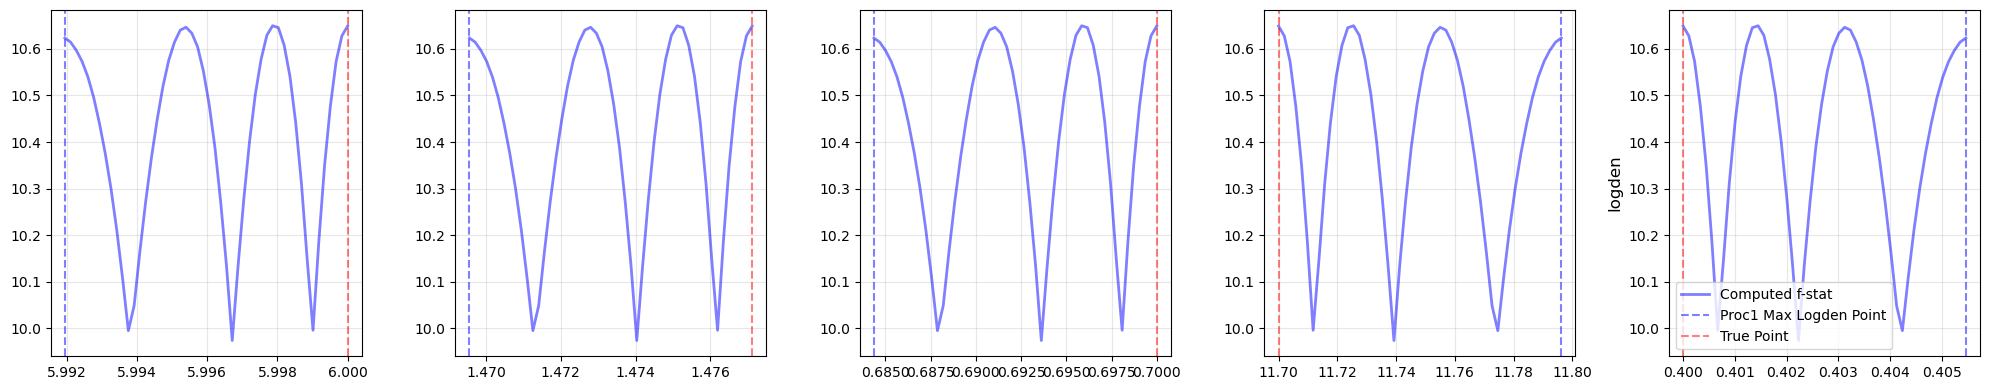

In [9]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')
    # ax.plot(line_points_proc2[dim], logden_theory_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    # ax.set_xlabel(labels[dim], fontsize=12)
#     ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [10]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [11]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat_timemax(data, template)
    X_proc1.append(X.get())

In [12]:
# templates_proc2 = []
# for point in line_points_proc2.T:
#     logm1, logm2, a, p0, e0 = point
#     m1 = 10**logm1
#     m2 = 10**logm2
#     template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
#                                  qS, phiS, qK, phiK, 
#                                  Phi_phi0, Phi_theta0, Phi_r0,
#                                  dt=dt, T=T)
#     templates_proc2.append(template)

In [13]:
# X_proc2 = []
# for template in templates_proc2:
#     X = gwf.Xstat(data, template)
#     X_proc2.append(X.get())

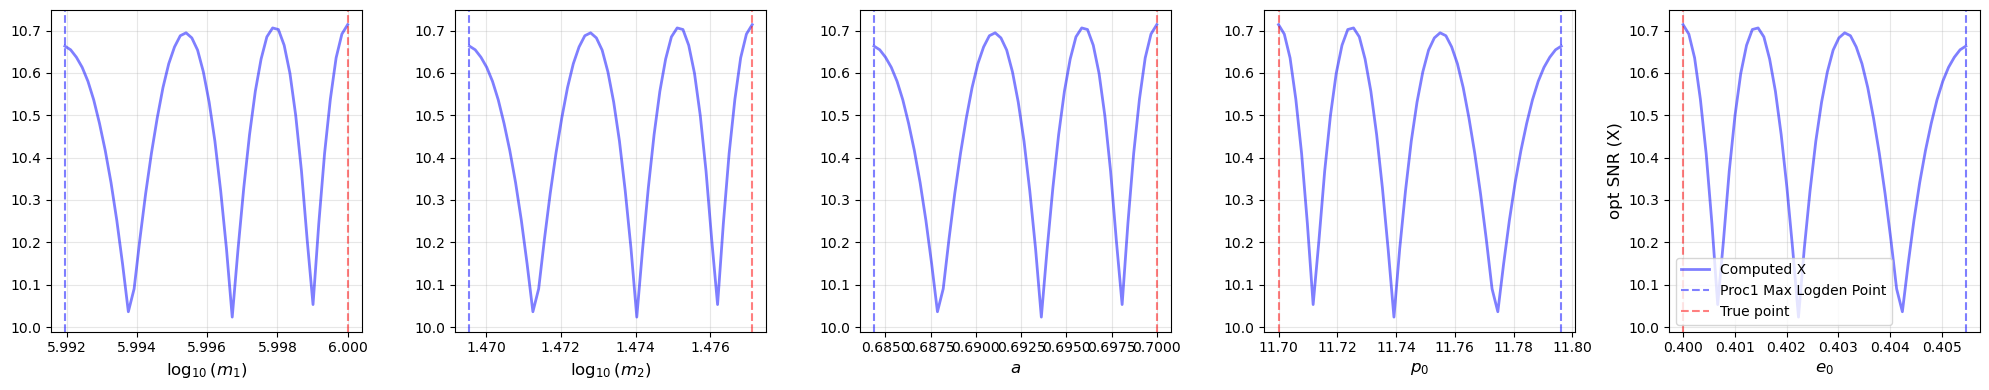

In [14]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X)', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')
#     ax.plot(line_points_proc2[dim], X_proc2, '-', 
#             color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
#     ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
#                alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [20]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat(data, template)
    X_proc1.append(X.get())

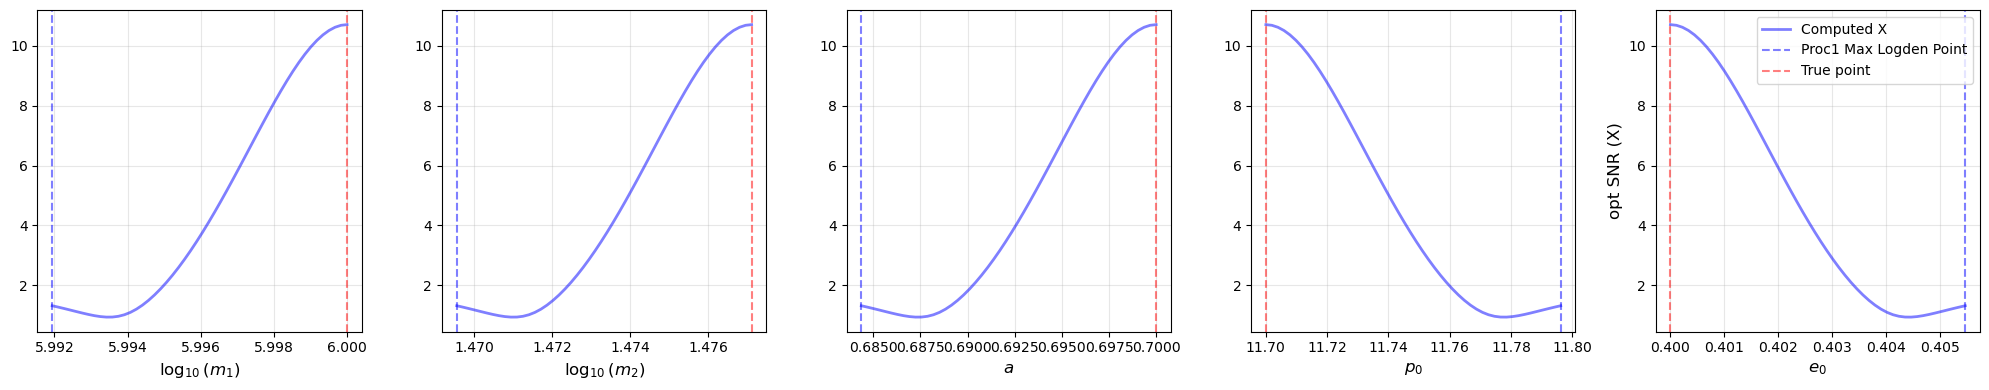

In [21]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X)', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')
#     ax.plot(line_points_proc2[dim], X_proc2, '-', 
#             color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
#     ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
#                alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [22]:
h_pt1 = waveform_gen_comb(10**5.9919396,10**1.46955437,  0.68436329, 11.79626924,  0.40546647, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)



In [26]:
h_pt2 = waveform_gen_comb(10**6.11536134,  10**1.58120197,  0.44167514, 11.57772703,  0.49714264,xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)

h_pt3 = waveform_gen_comb(10**6.12944065, 10**1.33809498, 0.76782457, 8.44862998, 0.49323371, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)

h_pt4 = waveform_gen_comb(10**6.02759147,  10**1.51976065,  0.61969702, 12.37215935,  0.51049576, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)



In [ ]:
gwf.Xstat_timemax(data, h_pt2), gwf.Xstat_timemax(data,h_pt3), gwf.Xstat_timemax(data,h_pt4) #orange, purple, red

(array(1.26341285), array(0.27918415), array(0.76396244))

In [ ]:
gwf.Xstat(data, h_pt1), gwf.Xstat_timemax(data,h_pt1), 

(array(1.31803496), array(10.66335866))

In [25]:
gwf.timemax_correlation(data, h_pt1) / (gwf.rhostat(h_pt1) * gwf.rhostat(h_pt1))

array(0.98280829)

In [15]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP (not combined)
    waveforms_per_group = []
    for group in groups:
        mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
                                          qS, phiS, qK, phiK, 
                                          Phi_phi0, Phi_theta0, Phi_r0,
                                          dt=dt, T=T,
                                          mode_selection=group,  # Pass group list
                                          include_minus_mkn=False)
        # Sum all modes within this group
        mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form_summed)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [16]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf.rhostat_modes(hm_arr.T))

In [17]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf.Xmstat_timemax(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)

In [18]:
chi2_proc1 = []
for i in range(len(mode_forms)):
    chi2 = gwf.chi_sq(Xm_proc1[i], rhostats_proc1[i])
    chi2_proc1.append(chi2.get())

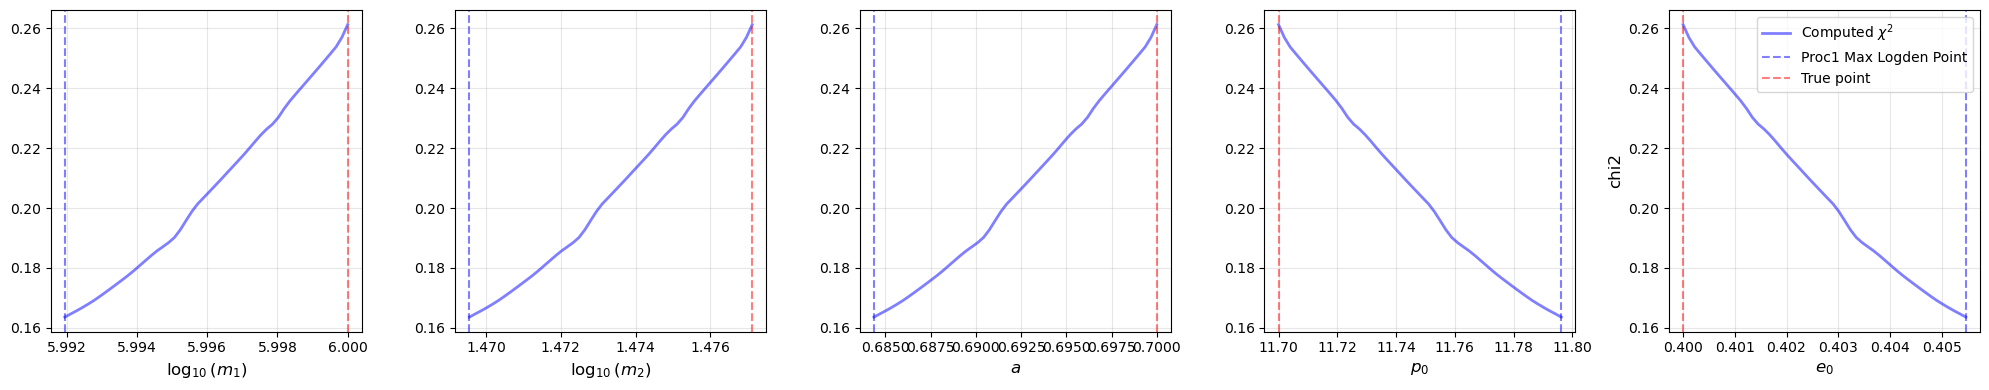

In [19]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label=r'Computed $\chi^2$')
    # ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()


In [ ]:
betas_proc1 = []
for rho_arr in rhostats_proc1:
    rho_tot = np.sqrt(np.sum(rho_arr**2))
    rho_dom_M = np.max(rho_arr)
    beta = gwf.calc_beta(rho_dom_M, rho_tot)
    betas_proc1.append(beta.get())

betas_proc1 = np.array(betas_proc1)

In [ ]:
f_theory = []
for i in range(0, 50):
    f_theor = X_proc1[i] * np.exp(-0.5 * betas_proc1[i] * chi2_proc1[i])
    print(f_theor)
    f_theory.append(f_theor)

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
for dim in range(5):
    ax = axs_1d[dim]

    ax.plot(line_points_proc1[dim], logden_theory_proc1/10, '-',
            color='blue', alpha=0.5, linewidth=2, label='lnL Proc1')
    ax.plot(line_points_proc1[dim], f_theory, '-',
            color='green', alpha=0.5, linewidth=2, label='F-stat Proc1')

    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--',
               alpha=0.5, label='Proc1 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--',
               alpha=0.5, label='True Point')

    ax.set_xlabel(labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()

In [ ]:
Xm_proc1

In [ ]:
X_scalars_proc1 = []
for i in range(len(Xm_proc1)):
    print('===')
    X_modes = Xm_proc1[i]          
    print('X_m: ', X_modes)
    rho_m = rhostats_proc1[i]     
    print('rho_m: ', rho_m)

    Xdotrho = cp.sum(X_modes * rho_m)
    print('Xdotrho: ', Xdotrho)
    rho_tot = cp.sqrt(cp.sum(cp.array(rho_m)**2))
    print('rho_tot: ', rho_tot)
    X_scalar = Xdotrho / rho_tot
    print('X_scalar: ', X_scalar)

    X_scalars_proc1.append(X_scalar.get())

X_scalars_proc1 = np.array(X_scalars_proc1)


In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X)', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_scalars_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')
#     ax.plot(line_points_proc2[dim], X_proc2, '-', 
#             color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
#     ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
#                alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
